In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression



In [21]:
model_scores_using_different_methods = {}

In [22]:
student_scores = pd.read_csv(r'Student_Performance.csv')
student_scores['Extracurricular Activities'] = np.where(student_scores['Extracurricular Activities'] == 'Yes' , 1 , 0)

In [23]:
student_scores.columns
student_scores.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [24]:
student_scores.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


In [25]:
student_scores.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


<Axes: >

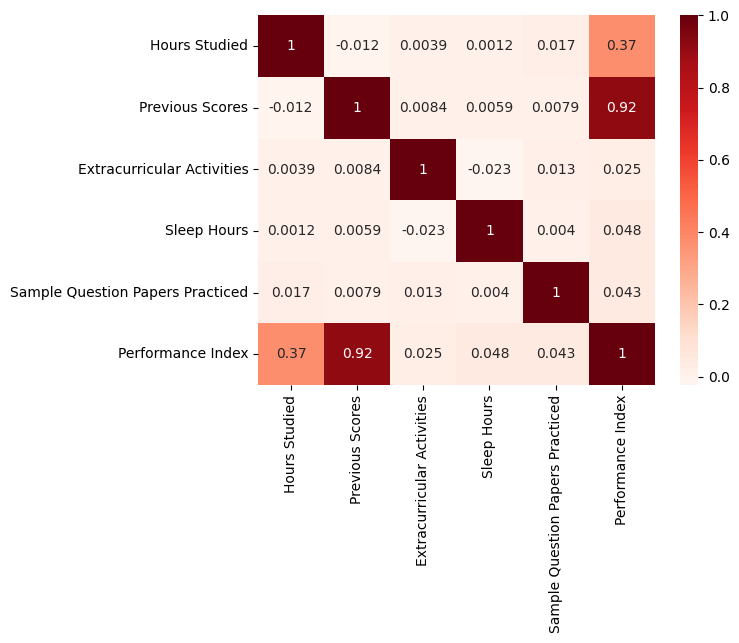

In [26]:
# plt.figure(figsize=(30,14))
sns.heatmap(student_scores.corr(),annot=True,cmap='Reds')

# One dimensional Linear Regression

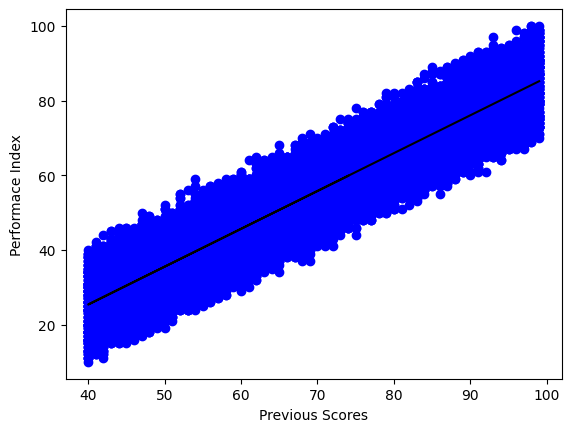

0.8375711642188022


In [27]:
reg = LinearRegression()
feature = student_scores.drop("Performance Index",axis=1).values
target = student_scores["Performance Index"].values

# PLotting Performance Index against Previous Scores
feature_PreviuosScore = feature[:,1]

# Reshaping it as a 2D array
feature_PreviuosScore = feature_PreviuosScore.reshape(-1,1)

reg.fit(feature_PreviuosScore,target)

predictions = reg.predict(feature_PreviuosScore)

# PLoting the points
plt.scatter(feature_PreviuosScore,target,color='blue')

# Plotting the best fit line
plt.plot(feature_PreviuosScore,predictions,color='black')

plt.ylabel("Performace Index")
plt.xlabel("Previous Scores")

plt.show()

print(reg.score(feature_PreviuosScore,target))


model_scores_using_different_methods['Linear Regression'] = reg.score(feature_PreviuosScore,target)

# Linear Regression using all Dimensions

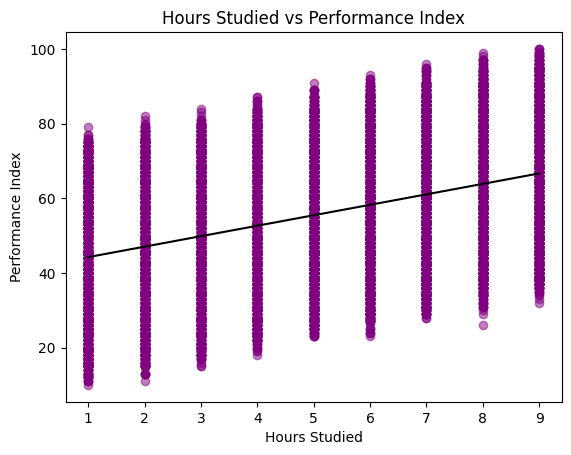

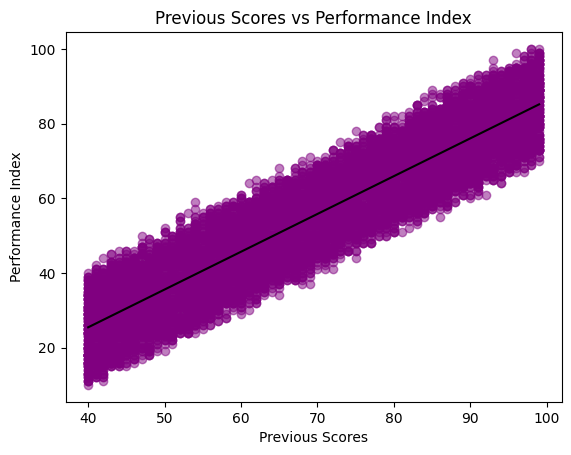

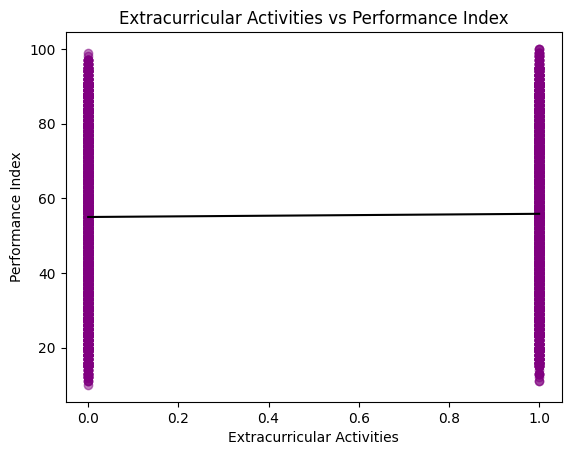

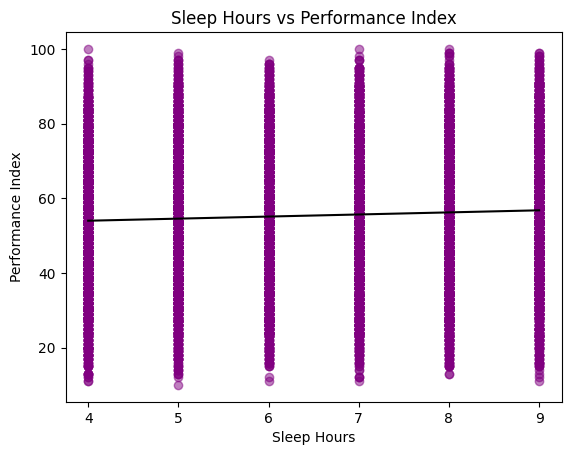

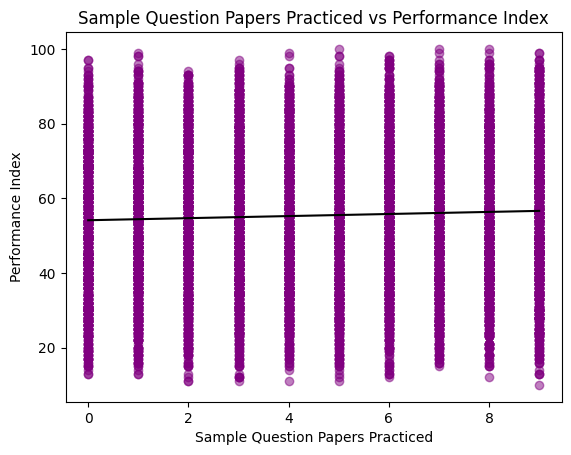

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = student_scores.drop("Performance Index",axis=1)
y = student_scores["Performance Index"]


for col in X.columns:
    X_feature = X[[col]].values
    X_train , X_test , y_train , y_test = train_test_split(X_feature,y,test_size=0.3,random_state=42)
    reg = LinearRegression()
    reg.fit(X_train,y_train)

    x_range = np.linspace(X_feature.min(), X_feature.max(), 100).reshape(-1, 1)
    y_pred = reg.predict(x_range)

    plt.figure()
    plt.scatter(X_feature, y, color='purple', alpha=0.5)
    plt.plot(x_range, y_pred, color='black')
    plt.xlabel(col)
    plt.ylabel("Performance Index")
    plt.title(f"{col} vs Performance Index")
    plt.show()


# R Squared 

In [29]:
from sklearn.model_selection import train_test_split
feature = student_scores.drop("Performance Index",axis=1).values
target = student_scores["Performance Index"].values
X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.3,random_state=42)

reg = LinearRegression()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
reg.score(X_test,y_test)

0.9890110607021136

# RMSE

In [30]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test , y_pred)

2.0165722957763483

# Ridge Regression

In [31]:
from sklearn.linear_model import Ridge
scores = []

for alpha in [0.1,1.0,10,100,1000]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train,y_train)
    y_pred = ridge.predict(X_test)
    scores.append(ridge.score(X_test,y_test))

print(scores)
model_scores_using_different_methods['Ridge Regression'] = max(scores)

[0.9890110593848406, 0.9890110474218479, 0.9890109172116528, 0.9890086173808481, 0.9889167808582895]


# Lasso Regression

In [32]:
from sklearn.linear_model import Lasso
scores = []
for alpha in [0.1,1.0,10,100,1000]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train,y_train)
    y_pred = lasso.predict(X_test)
    scores.append(lasso.score(X_test,y_test))

# print(scores)

print(np.mean(scores),np.std(scores))

model_scores_using_different_methods['Lasso Regression'] = max(scores)

0.7340061965953164 0.3779920018048744


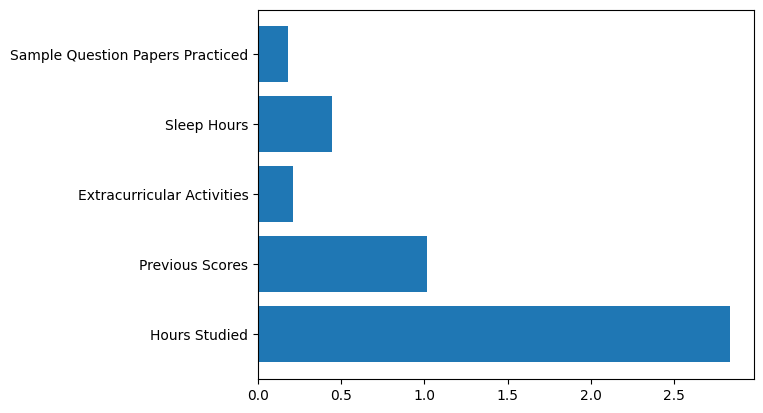

In [33]:
from sklearn.linear_model import Lasso
X = student_scores.drop("Performance Index",axis=1).values
Y = student_scores["Performance Index"].values
names = student_scores.drop("Performance Index",axis=1).columns
lasso = Lasso(alpha=0.1)
lasso_coef = lasso.fit(X,Y).coef_

plt.barh(names,lasso_coef)
# plt.xticks(rotation=45)
plt.show()

In [37]:
from sklearn.model_selection import cross_val_score , KFold
kf = KFold(n_splits=6 , shuffle=True , random_state=42)

cv_results = cross_val_score(reg,X,Y,cv=kf)
# print(cv_results)
print(np.mean(cv_results) , np.std(cv_results))

model_scores_using_different_methods['Scoress Validation'] = max(cv_results)

0.988728382878567 0.0004795771482019503


In [40]:
print(model_scores_using_different_methods)

{'Linear Regression': 0.8375711642188022, 'Ridge Regression': 0.9890110593848406, 'Lasso Regression': 0.9888237346108109, 'Scoress Validation': np.float64(0.9891043683934626)}


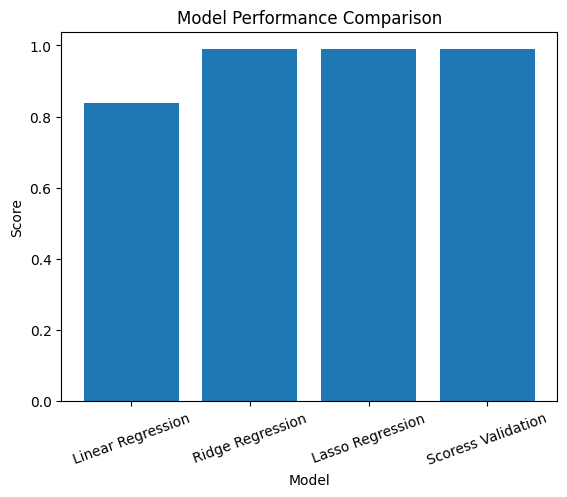

In [ ]:


plt.figure()
plt.bar(model_scores_using_different_methods.keys(), model_scores_using_different_methods.values())
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)

plt.show()